# 01 — Data Audit

## Projet : AI Business Advisor V2

### Objectif

cette étape vise à auditer les datasets bruts avant tout nettoyage , feature engineering ou entrainement de modéles .

les objectifs sont : 

- identifier la structure des datasets 
- verifier les types des variables 
- recherche les valeurs manqauntes 
- rechercher les doublons 
- analyser les identifiants 
- examiner les distributions générales 
- étudier les variables cibles 
- détecter les valeurs potentiellement incohérentes 
- mesurer le déséquilibre des classes 
- préparer les décisions de nettoyage 

Aucune modification des données originales n'est effectuée dans ce notebook 

In [3]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 

from pathlib import Path

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)
pd.set_option("display.width",200)


In [4]:
cwd = Path.cwd()

possible_paths = [
    cwd / "data" / "raw",
    cwd / "data-science" / "data" / "raw",
    cwd.parent / "data" / "raw"
]

RAW_DIR = None

for path in possible_paths:
    if path.exists():
        RAW_DIR = path
        break

if RAW_DIR is None:
    raise FileNotFoundError(
        "Impossible de localiser data/raw"
    )

print("Dossier raw :", RAW_DIR.resolve())

Dossier raw : C:\Users\user\ai-business-advisor-v2\data-science\data\raw


In [5]:
FREQ_PATH = RAW_DIR / "freMTPL2freq.csv"

FRAUD_PATH = RAW_DIR / "fraud_oracle.csv"

print("Frequency dataset :", FREQ_PATH)
print("Fraud dataset :", FRAUD_PATH)


Frequency dataset : c:\Users\user\ai-business-advisor-v2\data-science\data\raw\freMTPL2freq.csv
Fraud dataset : c:\Users\user\ai-business-advisor-v2\data-science\data\raw\fraud_oracle.csv


In [6]:
assert FREQ_PATH.exists(), "freMTPL2freq.csv introuvable"
assert FRAUD_PATH.exists(), "fraud_oracle.csv introuvable"

print("Les deux datasets sont diponibles")

Les deux datasets sont diponibles


In [7]:
df_freq = pd.read_csv(FREQ_PATH)

df_fraud = pd.read_csv(FRAUD_PATH)

In [8]:
print("Datasets chargés avec succès")

Datasets chargés avec succès


## 1. Dimension des datasets 

Nous vérifions le nombre d'observations et de variables disponibles 

In [9]:
print("freMTPLfreq")
print("Lignes  :", df_freq.shape[0])
print("Colonnes :", df_freq.shape[1])

print()

print("Vehicule Claim Fraud")
print("Lignes   :",df_fraud.shape[0])
print("Colonnes :",df_fraud.shape[1])

freMTPLfreq
Lignes  : 678013
Colonnes : 12

Vehicule Claim Fraud
Lignes   : 15420
Colonnes : 33


###  Observation 

Le dataset freMTPLfreq contient 678013 contrats/polices et 12 variables 

Le dataset de fraude contient 15420 observations et 33 varibales 

les deux datasets ont donc des tailles et des structures trés différentes 
Ils ne représentent pas la meme population et ne devront pas etre fusionnées artificiellement 

In [10]:
df_freq.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,76,R72


In [11]:
df_fraud.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


## Dictionnaire initial — freMTPL2freq

| Variable | Interprétation |
|---|---|
| IDpol | Identifiant de la police |
| ClaimNb | Nombre de sinistres |
| Exposure | Durée d'exposition au risque |
| Area | Zone géographique |
| VehPower | Puissance du véhicule |
| VehAge | Âge du véhicule |
| DrivAge | Âge du conducteur |
| BonusMalus | Coefficient bonus-malus |
| VehBrand | Groupe/marque du véhicule |
| VehGas | Type de carburant |
| Density | Densité de population |
| Region | Région |

In [12]:
print("=== freMTPLfreq ===")
print(df_freq.dtypes)


print()


print("=== Fraud ===")
print(df_fraud.dtypes)

=== freMTPLfreq ===
IDpol         float64
ClaimNb         int64
Exposure      float64
Area              str
VehPower        int64
VehAge          int64
DrivAge         int64
BonusMalus      int64
VehBrand          str
VehGas            str
Density         int64
Region            str
dtype: object

=== Fraud ===
Month                     str
WeekOfMonth             int64
DayOfWeek                 str
Make                      str
AccidentArea              str
DayOfWeekClaimed          str
MonthClaimed              str
WeekOfMonthClaimed      int64
Sex                       str
MaritalStatus             str
Age                     int64
Fault                     str
PolicyType                str
VehicleCategory           str
VehiclePrice              str
FraudFound_P            int64
PolicyNumber            int64
RepNumber               int64
Deductible              int64
DriverRating            int64
Days_Policy_Accident      str
Days_Policy_Claim         str
PastNumberOfClaims        s

In [13]:
freq_numeric = df_freq.select_dtypes(include=np.number).columns.tolist()

freq_categorical = df_freq.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numériques : ")
print(freq_numeric)

print()

print("Variables catégorielles : ")
print(freq_categorical)

Variables numériques : 
['IDpol', 'ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density']

Variables catégorielles : 
['Area', 'VehBrand', 'VehGas', 'Region']


In [14]:
fraud_numeric = df_fraud.select_dtypes(include=np.number).columns.tolist()

fraud_categorical = df_fraud.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numériques : ")
print(fraud_numeric)

print()

print("Variables catégorielles : ")
print(fraud_categorical)

Variables numériques : 
['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']

Variables catégorielles : 
['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'BasePolicy']


In [15]:
missing_freq = pd.DataFrame({
    "missing_count":df_freq.isna().sum(),
    "missing_percent":(
        df_freq.isna().mean() * 100
    )
})

missing_freq

,missing_count,missing_percent
IDpol,0,0.0
ClaimNb,0,0.0
Exposure,0,0.0
Area,0,0.0
VehPower,0,0.0
VehAge,0,0.0
DrivAge,0,0.0
BonusMalus,0,0.0
VehBrand,0,0.0
VehGas,0,0.0


In [16]:
missing_fraud = pd.DataFrame({
    "missing_count": df_fraud.isna().sum(),
    "missing_percent":(
        df_fraud.isna().mean() * 100
    )
})

missing_fraud.sort_values(
    "missing_percent",
    ascending=False
)

,missing_count,missing_percent
Month,0,0.0
WeekOfMonth,0,0.0
DayOfWeek,0,0.0
Make,0,0.0
AccidentArea,0,0.0
DayOfWeekClaimed,0,0.0
MonthClaimed,0,0.0
WeekOfMonthClaimed,0,0.0
Sex,0,0.0
MaritalStatus,0,0.0


In [17]:
special_values = [
    "none",
    "unknown",
    "?",
    "na",
    "n/a",
    "",
    "0"
]

for col in fraud_categorical:

    values = (
        df_fraud[col]
        .astype(str)
        .str.lower()
        .value_counts()
    )
    
    matches = values[
        values.index.isin(special_values)
    ]

    if not matches.empty:

        print(f"\n{col}")
        print(matches)


DayOfWeekClaimed
DayOfWeekClaimed
0    1
Name: count, dtype: int64

MonthClaimed
MonthClaimed
0    1
Name: count, dtype: int64

Days_Policy_Accident
Days_Policy_Accident
none    55
Name: count, dtype: int64

Days_Policy_Claim
Days_Policy_Claim
none    1
Name: count, dtype: int64

PastNumberOfClaims
PastNumberOfClaims
none    4352
Name: count, dtype: int64

NumberOfSuppliments
NumberOfSuppliments
none    7047
Name: count, dtype: int64


In [18]:
df_fraud[
    (df_fraud["DayOfWeekClaimed"].astype(str) == "0")
    |
    (df_fraud["MonthClaimed"].astype(str) == "0")
]

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
1516,Jul,2,Monday,Honda,Rural,0,0,1,Male,Single,0,Policy Holder,Sedan - All Perils,Sedan,more than 69000,0,1517,15,400,2,more than 30,none,none,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,All Perils


### Anomalie détectée 

Une observation contient la valeur "0" pour 'MonthClaimed' et 'DayOfWeekClaimed' .

Ces valeurs ne correspendent pas aux catégories calendaires attendues .
Cette observation devra etre examinée lors de l'étape de nettoyage 

In [19]:
freq_duplicates = df_freq.duplicated().sum()

print(
    "Nombre de lignes dupliquées :",
    freq_duplicates
)

Nombre de lignes dupliquées : 0


In [20]:
fraud_duplicates = df_fraud.duplicated().sum()

print(
    "Nombre de lignes dupliquées :",
    fraud_duplicates
)

Nombre de lignes dupliquées : 0


Aucun doublon exact n'a été identifié dans les deux datasets.

In [21]:
print(
    "Nombre de lignes :",
    len(df_freq)
)

print("Nombre d'IDpl uniques :",
      df_freq["IDpol"].nunique()
)

print(
    "IDpol dupliqués :",
    df_freq["IDpol"].duplicated().sum()
)

Nombre de lignes : 678013
Nombre d'IDpl uniques : 678013
IDpol dupliqués : 0


In [22]:
print(
    "Nombre de lignes :",
    len(df_fraud)
)

print(
    "PolicyNumber uniques :",
    df_fraud["PolicyNumber"].nunique()
)

print(
    "Doublons de PolicyNumber :",
    df_fraud["PolicyNumber"].duplicated().sum()
)

Nombre de lignes : 15420
PolicyNumber uniques : 15420
Doublons de PolicyNumber : 0


In [23]:
df_freq.describe().T

,count,mean,std,min,25%,50%,75%,max
IDpol,678013.0,2.621857e+06,1.641783e+06,1.000000,1157951.00,2272152.00,4046274.00,6114330.00
ClaimNb,678013.0,5.324677e-02,2.401173e-01,0.000000,0.00,0.00,0.00,16.00
Exposure,678013.0,5.287501e-01,3.644415e-01,0.002732,0.18,0.49,0.99,2.01
VehPower,678013.0,6.454631e+00,2.050906e+00,4.000000,5.00,6.00,7.00,15.00
VehAge,678013.0,7.044265e+00,5.666232e+00,0.000000,2.00,6.00,11.00,100.00
DrivAge,678013.0,4.549912e+01,1.413744e+01,18.000000,34.00,44.00,55.00,100.00
BonusMalus,678013.0,5.976150e+01,1.563666e+01,50.000000,50.00,50.00,64.00,230.00
Density,678013.0,1.792422e+03,3.958647e+03,1.000000,92.00,393.00,1658.00,27000.00


In [25]:
freq_summary = df_freq.describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

freq_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
IDpol,678013.0,2.621857e+06,1.641783e+06,1.000000,19934.240000,69365.60,1157951.00,2272152.00,4046274.00,6014195.2,6105127.76,6114330.00
ClaimNb,678013.0,5.324677e-02,2.401173e-01,0.000000,0.000000,0.00,0.00,0.00,0.00,1.0,1.00,16.00
Exposure,678013.0,5.287501e-01,3.644415e-01,0.002732,0.008219,0.04,0.18,0.49,0.99,1.0,1.00,2.01
VehPower,678013.0,6.454631e+00,2.050906e+00,4.000000,4.000000,4.00,5.00,6.00,7.00,11.0,13.00,15.00
VehAge,678013.0,7.044265e+00,5.666232e+00,0.000000,0.000000,0.00,2.00,6.00,11.00,17.0,21.00,100.00
DrivAge,678013.0,4.549912e+01,1.413744e+01,18.000000,20.000000,25.00,34.00,44.00,55.00,72.0,80.00,100.00
BonusMalus,678013.0,5.976150e+01,1.563666e+01,50.000000,50.000000,50.00,50.00,50.00,64.00,95.0,106.00,230.00
Density,678013.0,1.792422e+03,3.958647e+03,1.000000,10.000000,20.00,92.00,393.00,1658.00,7313.0,27000.00,27000.00


In [26]:
(df_freq["Exposure"]>1).sum()

np.int64(1224)

In [27]:
df_freq["VehAge"].describe(percentiles=[0.01, 0.05, 0.99])

count    678013.000000
mean          7.044265
std           5.666232
min           0.000000
1%            0.000000
5%            0.000000
99%          21.000000
max         100.000000
Name: VehAge, dtype: float64

In [28]:
df_freq["DrivAge"].describe(percentiles=[0.01, 0.05, 0.99])

count    678013.000000
mean         45.499122
std          14.137444
min          18.000000
1%           20.000000
5%           25.000000
99%          80.000000
max         100.000000
Name: DrivAge, dtype: float64

In [29]:
df_freq["BonusMalus"].describe(percentiles=[0.01, 0.05, 0.99])

count    678013.000000
mean         59.761502
std          15.636658
min          50.000000
1%           50.000000
5%           50.000000
99%         106.000000
max         230.000000
Name: BonusMalus, dtype: float64

In [30]:
claim_counts = (
    df_freq["ClaimNb"]
    .value_counts()
    .sort_index()
)

claim_counts

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

In [ ]:
has_claim = (
    df_freq["ClaimNb"] > 0
).astype(int)

In [32]:
has_claim.value_counts()

ClaimNb
0    643953
1     34060
Name: count, dtype: int64

In [33]:
has_claim.value_counts(
    normalize=True
) * 100

ClaimNb
0    94.976498
1     5.023502
Name: proportion, dtype: float64

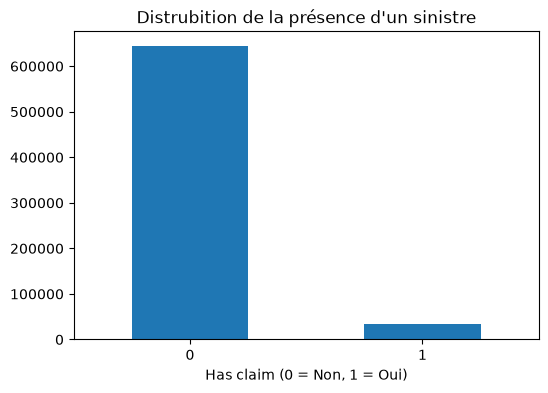

In [34]:
claim_binary_counts = has_claim.value_counts().sort_index()

plt.figure(figsize=(6,4))

claim_binary_counts.plot(
    kind="bar"
)

plt.title(
    "Distrubition de la présence d'un sinistre"
)

plt.xlabel(
    "Has claim (0 = Non, 1 = Oui)"
)

plt.xticks(rotation=0)

plt.show()

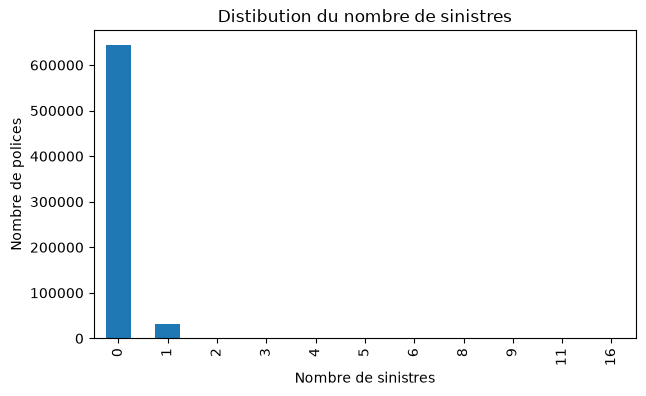

In [35]:
plt.figure(figsize=(7,4))

df_freq["ClaimNb"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title(
    "Distibution du nombre de sinistres"
)

plt.xlabel(
    "Nombre de sinistres"
)

plt.ylabel(
    "Nombre de polices"
)

plt.show()

In [41]:
def categorical_summary(df,columns):

    rows = []

    for col in columns:

        rows.append({
            "column": col,
            "n_unique": df[col].nunique(),
            "most_frequent" : df[col].mode().iloc[0],
            "most_frequent_count": df[col].value_counts().iloc[0]

        })

        return pd.DataFrame(rows)

In [42]:
categorical_summary(
    df_freq,
    freq_categorical    
)

,column,n_unique,most_frequent,most_frequent_count
0,Area,6,C,191880


In [43]:
df_freq["VehGas"].value_counts()

VehGas
Regular    345877
Diesel     332136
Name: count, dtype: int64

In [44]:
df_freq["Region"].value_counts()

Region
R24    160601
R82     84752
R93     79315
R11     69791
R53     42122
R52     38751
R91     35805
R72     31329
R31     27285
R54     19046
R73     17141
R41     12990
R25     10893
R26     10492
R23      8784
R22      7994
R83      5287
R74      4567
R94      4516
R21      3026
R42      2200
R43      1326
Name: count, dtype: int64

# Audit du dataset Vehicule Claim Fraud 

Ce dataset sera traité indépendemment de freMTPL2.

Il est detiné à une tache supervisée de classification binaire : 

- 0 : observation non frauduleuse ;
- 1 : fraude identifiée.

In [45]:
fraud_counts = (
    df_fraud["FraudFound_P"]
    .value_counts()
    .sort_index()
)

fraud_counts

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

In [46]:
fraud_percent = (
    df_fraud["FraudFound_P"]
    .value_counts(normalize=True)
    .sort_index() * 100 
)

fraud_percent

FraudFound_P
0    94.014267
1     5.985733
Name: proportion, dtype: float64

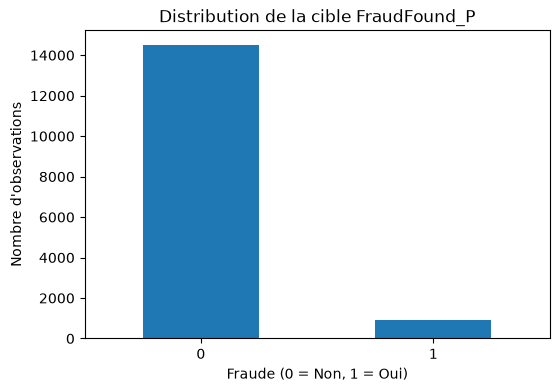

In [47]:
plt.figure(figsize=(6,4))

fraud_counts.plot(
    kind="bar"
)

plt.title(
    "Distribution de la cible FraudFound_P"
)

plt.xlabel(
    "Fraude (0 = Non, 1 = Oui)"
)

plt.ylabel(
    "Nombre d'observations"
)

plt.xticks(rotation=0)

plt.show()

In [48]:
df_fraud["Age"].describe()

count    15420.000000
mean        39.855707
std         13.492377
min          0.000000
25%         31.000000
50%         38.000000
75%         48.000000
max         80.000000
Name: Age, dtype: float64

In [49]:
(df_fraud["Age"] == 0).sum()

np.int64(320)

In [51]:
df_fraud.loc[
    df_fraud["Age"] == 0,
    "AgeOfPolicyHolder"
].value_counts()

AgeOfPolicyHolder
16 to 17    320
Name: count, dtype: int64

320 observations possèdent Age = 0

Toutes ces observations appartiennent à la catégorie 
AgeOfPolicyHolder = "16 to 17"

Cette association suggère que la valeur 0 pourraint etre un codage spécial plutot qu'un age reel 

La documentation du dataset devra etre consulté avant toute correction 

In [53]:
df_fraud[
    [
        "RepNumber",
        "DriverRating",
        "Deductible",
        "Year"
    ]
].nunique()

RepNumber       16
DriverRating     4
Deductible       4
Year             3
dtype: int64

In [55]:
fraud_cardinality = pd.DataFrame({
    "dtype": df_fraud.dtypes.astype(str),
    "n_unique": df_fraud.nunique()
}).sort_values(
    "n_unique"
)

fraud_cardinality

,dtype,n_unique
AccidentArea,str,2
FraudFound_P,int64,2
Fault,str,2
Sex,str,2
AgentType,str,2
PoliceReportFiled,str,2
WitnessPresent,str,2
VehicleCategory,str,3
Year,int64,3
BasePolicy,str,3


In [56]:
for col in fraud_categorical:

    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)

    print(
        df_fraud[col]
        .value_counts(dropna=False)
    )


Month
Month
Jan    1411
May    1367
Mar    1360
Jun    1321
Oct    1305
Dec    1285
Apr    1280
Feb    1266
Jul    1257
Sep    1240
Nov    1201
Aug    1127
Name: count, dtype: int64

DayOfWeek
DayOfWeek
Monday       2616
Friday       2445
Tuesday      2300
Thursday     2173
Wednesday    2159
Saturday     1982
Sunday       1745
Name: count, dtype: int64

Make
Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Dodge         109
Saab          108
Mercury        83
Saturn         58
Nisson         30
BMW            15
Jaguar          6
Porche          5
Mecedes         4
Ferrari         2
Lexus           1
Name: count, dtype: int64

AccidentArea
AccidentArea
Urban    13822
Rural     1598
Name: count, dtype: int64

DayOfWeekClaimed
DayOfWeekClaimed
Monday       3757
Tuesday      3375
Wednesday    2951
Thursday     2660
Friday       2497
Saturday      127
Sunday         52
0               1
Nam

In [58]:
checks_freq = {

    "Exposure <= 0":
        (df_freq["Exposure"] <= 0
        ).sum(),

    "Exposure > 1": 
        (df_freq["Exposure"] > 1
        ).sum(),

    "ClaimNb < 0":
        (df_freq["ClaimNb"] < 0
        ).sum(),

    "VehAge < 0":
        (df_freq["VehAge"] < 0
        ).sum(),

    "DrivAge < 18":
        (df_freq["DrivAge"] < 18
        ).sum(),

    "BonusMalus < 0":
        (df_freq["BonusMalus"] < 0
        ).sum(),

    "Density <= 0":
        (df_freq["Density"] <= 0
        ).sum()

}

pd.Series(
    checks_freq,
    name="count"
)




Exposure <= 0        0
Exposure > 1      1224
ClaimNb < 0          0
VehAge < 0           0
DrivAge < 18         0
BonusMalus < 0       0
Density <= 0         0
Name: count, dtype: int64

In [59]:
def percentile_report(
        df,
        columns
):
    return df[columns].quantile(
        [
        0.00,
        0.01,
        0.05,
        0.25,
        0.5,
        0.75,
        0.95,
        0.99,
        1.00
        ]
    ).T

In [60]:
percentile_report(
    df_freq,
    [
        "Exposure",
        "VehPower",
        "VehAge",
        "DrivAge",
        "BonusMalus",
        "Density"
    ]
)

,0.00,0.01,0.05,0.25,0.50,0.75,0.95,0.99,1.00
Exposure,0.002732,0.008219,0.04,0.18,0.49,0.99,1.0,1.0,2.01
VehPower,4.000000,4.000000,4.00,5.00,6.00,7.00,11.0,13.0,15.00
VehAge,0.000000,0.000000,0.00,2.00,6.00,11.00,17.0,21.0,100.00
DrivAge,18.000000,20.000000,25.00,34.00,44.00,55.00,72.0,80.0,100.00
BonusMalus,50.000000,50.000000,50.00,50.00,50.00,64.00,95.0,106.0,230.00
Density,1.000000,10.000000,20.00,92.00,393.00,1658.00,7313.0,27000.0,27000.00


In [63]:
def data_quality_summary(df):

    return pd.DataFrame({
        "dtype":
            df.dtypes.astype(str),

        "missing":
            df.isna().sum(),

        "missing_percent":
            (df.isna().mean() * 100).round(3),

        "unique":
            df.nunique(),

        "unique_pct":
            (df.nunique() / len(df) * 100).round(3)

    })

In [64]:
freq_quality = data_quality_summary(df_freq)

freq_quality

,dtype,missing,missing_percent,unique,unique_pct
IDpol,float64,0,0.0,678013,100.000
ClaimNb,int64,0,0.0,11,0.002
Exposure,float64,0,0.0,187,0.028
Area,str,0,0.0,6,0.001
VehPower,int64,0,0.0,12,0.002
VehAge,int64,0,0.0,78,0.012
DrivAge,int64,0,0.0,83,0.012
BonusMalus,int64,0,0.0,115,0.017
VehBrand,str,0,0.0,11,0.002
VehGas,str,0,0.0,2,0.000


In [67]:
fraud_quality = data_quality_summary(
    df_fraud
)

fraud_quality

,dtype,missing,missing_percent,unique,unique_pct
Month,str,0,0.0,12,0.078
WeekOfMonth,int64,0,0.0,5,0.032
DayOfWeek,str,0,0.0,7,0.045
Make,str,0,0.0,19,0.123
AccidentArea,str,0,0.0,2,0.013
DayOfWeekClaimed,str,0,0.0,8,0.052
MonthClaimed,str,0,0.0,13,0.084
WeekOfMonthClaimed,int64,0,0.0,5,0.032
Sex,str,0,0.0,2,0.013
MaritalStatus,str,0,0.0,4,0.026


In [65]:
REPORT_DIR = RAW_DIR.parent.parent / "reports" / "data_audit"

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [68]:
freq_quality.to_csv(
    REPORT_DIR / "freMTPL2freq_quality.csv"
)

fraud_quality.to_csv(
    REPORT_DIR / "fraud_quality.csv"
)

# Bilan — freMTPL2freq

## Structure

- Nombre d'observations : 678 013
- Nombre de variables : 12
- Identifiant : IDpol
- IDpol uniques : 678 013
- Doublons exacts : 0
- Valeurs NaN détectées : 0

## Cible

La variable ClaimNb représente le nombre de sinistres.

La grande majorité des contrats ne possède aucun sinistre.

En transformant temporairement ClaimNb en une cible binaire
`has_claim = ClaimNb > 0`, environ 5,02 % des observations
présentent au moins un sinistre.

La future tâche de classification sera donc fortement déséquilibrée.

## Points à investiguer

- IDpol est stocké en float alors qu'il représente un identifiant.
- 1 224 observations présentent Exposure > 1.
- VehAge possède des valeurs allant jusqu'à 100.
- DrivAge atteint 100.
- BonusMalus atteint 230.
- Density est fortement asymétrique et atteint 27 000.

Ces observations ne seront pas supprimées automatiquement.
Elles devront être comparées à la documentation et analysées
durant les étapes EDA et Cleaning.

## Utilisation prévue

Ce dataset pourra être utilisé pour :

- occurrence d'un sinistre ;
- fréquence des sinistres.

Il ne contient cependant pas ClaimAmount.
Il ne suffit donc pas à construire seul un modèle de sévérité
ou de prime pure.

# Bilan — Vehicle Claim Fraud

## Structure

- Nombre d'observations : 15 420
- Nombre de variables : 33
- Identifiant : PolicyNumber
- PolicyNumber uniques : 15 420
- Doublons exacts : 0
- Valeurs NaN détectées : 0

## Cible

La cible est FraudFound_P :

- 14 497 observations non frauduleuses ;
- 923 observations frauduleuses.

La fraude représente environ 5,99 % du dataset.

Le problème est donc fortement déséquilibré.

L'accuracy seule ne sera pas appropriée pour l'évaluation
du futur modèle.

## Anomalies / éléments à investiguer

- 320 observations ont Age = 0.
- Ces 320 observations appartiennent toutes à AgeOfPolicyHolder = "16 to 17".
- Une observation possède MonthClaimed = "0".
- La même observation possède DayOfWeekClaimed = "0".
- Plusieurs variables catégorielles utilisent la valeur "none".
- Il faudra distinguer les véritables absences d'information
  des catégories métier signifiant réellement "aucun".

## Types des variables

Certaines variables stockées comme numériques sont plutôt
des variables catégorielles ou ordinales :

- RepNumber ;
- DriverRating ;
- Year.

Cette distinction devra être prise en compte dans le preprocessing.

## Utilisation prévue

Ce dataset sera utilisé exclusivement pour la détection de fraude.

Il ne sera pas fusionné artificiellement avec freMTPL2.

# Conclusion du Data Audit

Les deux datasets sont exploitables mais représentent deux tâches
différentes.

## freMTPL2freq

Objectif :
- occurrence des sinistres ;
- fréquence des sinistres.

Problèmes principaux :
- déséquilibre de la cible ;
- outliers potentiels ;
- Exposure > 1 à investiguer ;
- certaines variables nécessitent une validation métier.

## Vehicle Claim Fraud

Objectif :
- classification fraude / non fraude.

Problèmes principaux :
- fort déséquilibre de classes ;
- Age = 0 pour 320 observations ;
- une observation avec des valeurs calendaires "0" ;
- présence de catégories spéciales telles que "none".

## Décision

Aucune donnée n'est encore supprimée ou transformée.

La prochaine étape sera une analyse exploratoire détaillée (EDA)
afin de comprendre les distributions, relations entre variables
et relations avec les variables cibles avant toute décision de nettoyage.